In [65]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from tqdm.contrib.itertools import product

# NDLib
import networkx as nx
import ndlib.models.epidemics as ep
import ndlib.models.ModelConfig as mc
from ndlib.utils import multi_runs

# Rng
rng = np.random.default_rng(14105071)
import random
random.seed(14105071)
np.random.seed(14105071)

# Matplotlib Config
%matplotlib inline
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = [8, 8]

In [66]:
def simulate_SIR_n_times(graph, beta, gamma, i0, n_executions, n_iterations):
    """
    Return an array with trend data

    Parameters:
        graph (networkx graph): Graph on which the SIR model is executed
        beta (float): Beta parameter
        gamma (float): Gamma parameter
        i0 (float): Fraction of total population that is infected at t=0
        n_executions (int): The number of times the model is ran
        n_iterations (int): The number of iterations each run of the model executes.

    Returns:
        model_data (numpy array) : m * 3 * n array with m rows for each execution and n pages for each iteration.
    """
    # Set up model with parameters
    model = ep.SIRModel(graph)
    config = mc.Configuration()
    config.add_model_parameter('beta', beta)
    config.add_model_parameter('gamma', gamma)
    config.add_model_parameter('fraction_infected', i0)
    model.set_initial_status(config)

    # Run model(s)
    trends = multi_runs(model, execution_number=n_executions, iteration_number=n_iterations, infection_sets=None)

    # Data manipulation
    model_data = list()
    for execution in trends:
        s = execution['trends']['node_count'][0]
        i = execution['trends']['node_count'][1]
        r = execution['trends']['node_count'][2]
        model_data.append([s,i,r])

    return np.array(model_data)



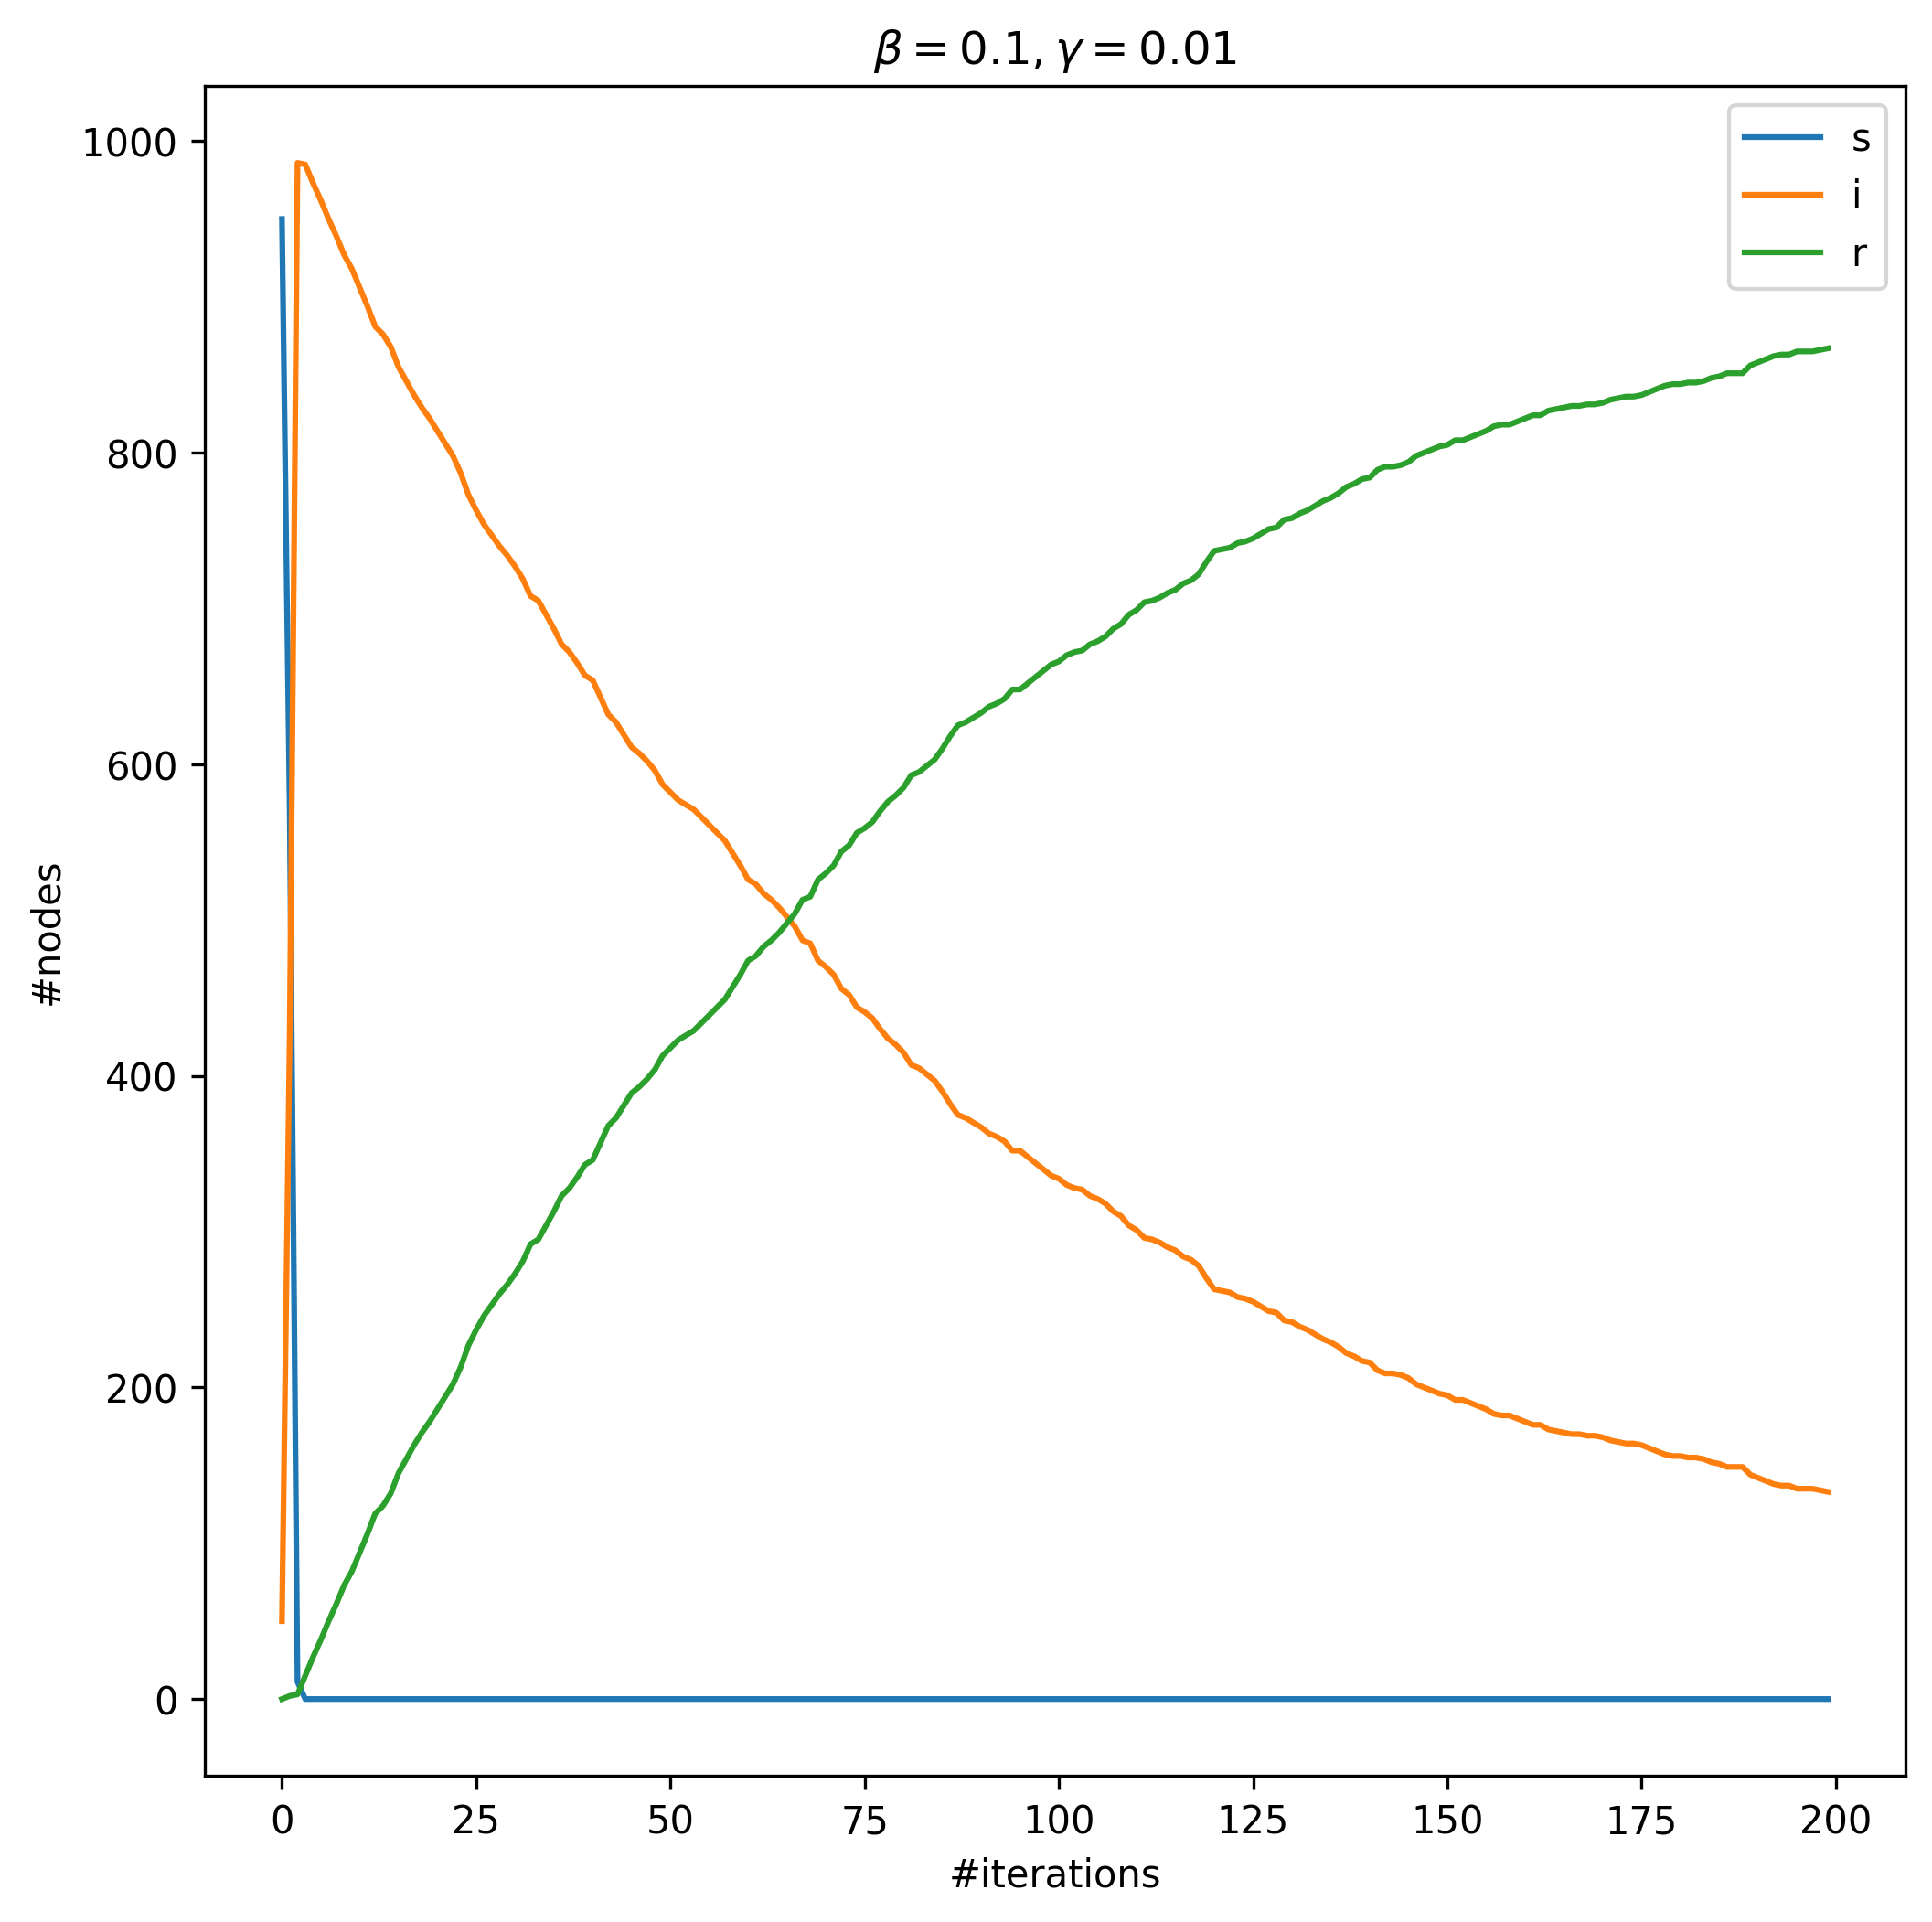

In [67]:
graph1 = nx.erdos_renyi_graph(1000, 0.1)
implement_and_simulate = simulate_SIR_n_times(graph1, 0.1, 0.01, 0.05, 1, 200)
s = implement_and_simulate[0,0]
i = implement_and_simulate[0,1]
r = implement_and_simulate[0,2]
plt.title(f"$\\beta = 0.1, \\gamma = 0.01$")
plt.ylabel("#nodes")
plt.xlabel("#iterations")
plt.plot(range(len(s)), s, label="s")
plt.plot(range(len(i)), i, label="i")
plt.plot(range(len(r)), r, label="r")
plt.legend()

#### Comparing different graphs
Try to make graphs with same amount of nodes and a similar diameter ±10% and average node degree

In [68]:
def make_n_graphs(params, algorithm, nodes=1000,  n=5):
    """ 
    Return a list of n graphs

    Parameters:
        params (list): a list with values for n, p_er, m, k, p_ws Which are used as parameters in graph creation
        algorithm (str): a two letter code to specify which generation algorithm is used (er|ba|ws)
        n (int): number of graphs to generate
    
    Returns:
        graphs (list): list containing n graph

    """
    graphs = list()
    if algorithm == "er":
        for i in range(n):
            graphs.append(nx.erdos_renyi_graph(nodes, params[0]))
    elif algorithm == "ba":
        for i in range(n):
            graphs.append(nx.barabasi_albert_graph(nodes, params[1]))
    else:
        for i in range(n):
            graphs.append(nx.connected_watts_strogatz_graph(nodes, params[2], params[3]))
    return graphs


In [69]:
params = [0.011, 4, 15, 0.4]

In [70]:
er_graphs = make_n_graphs(params, 'er', n=10)
ba_graphs = make_n_graphs(params, 'ba', n=10)
ws_graphs = make_n_graphs(params, 'ws', n=10)


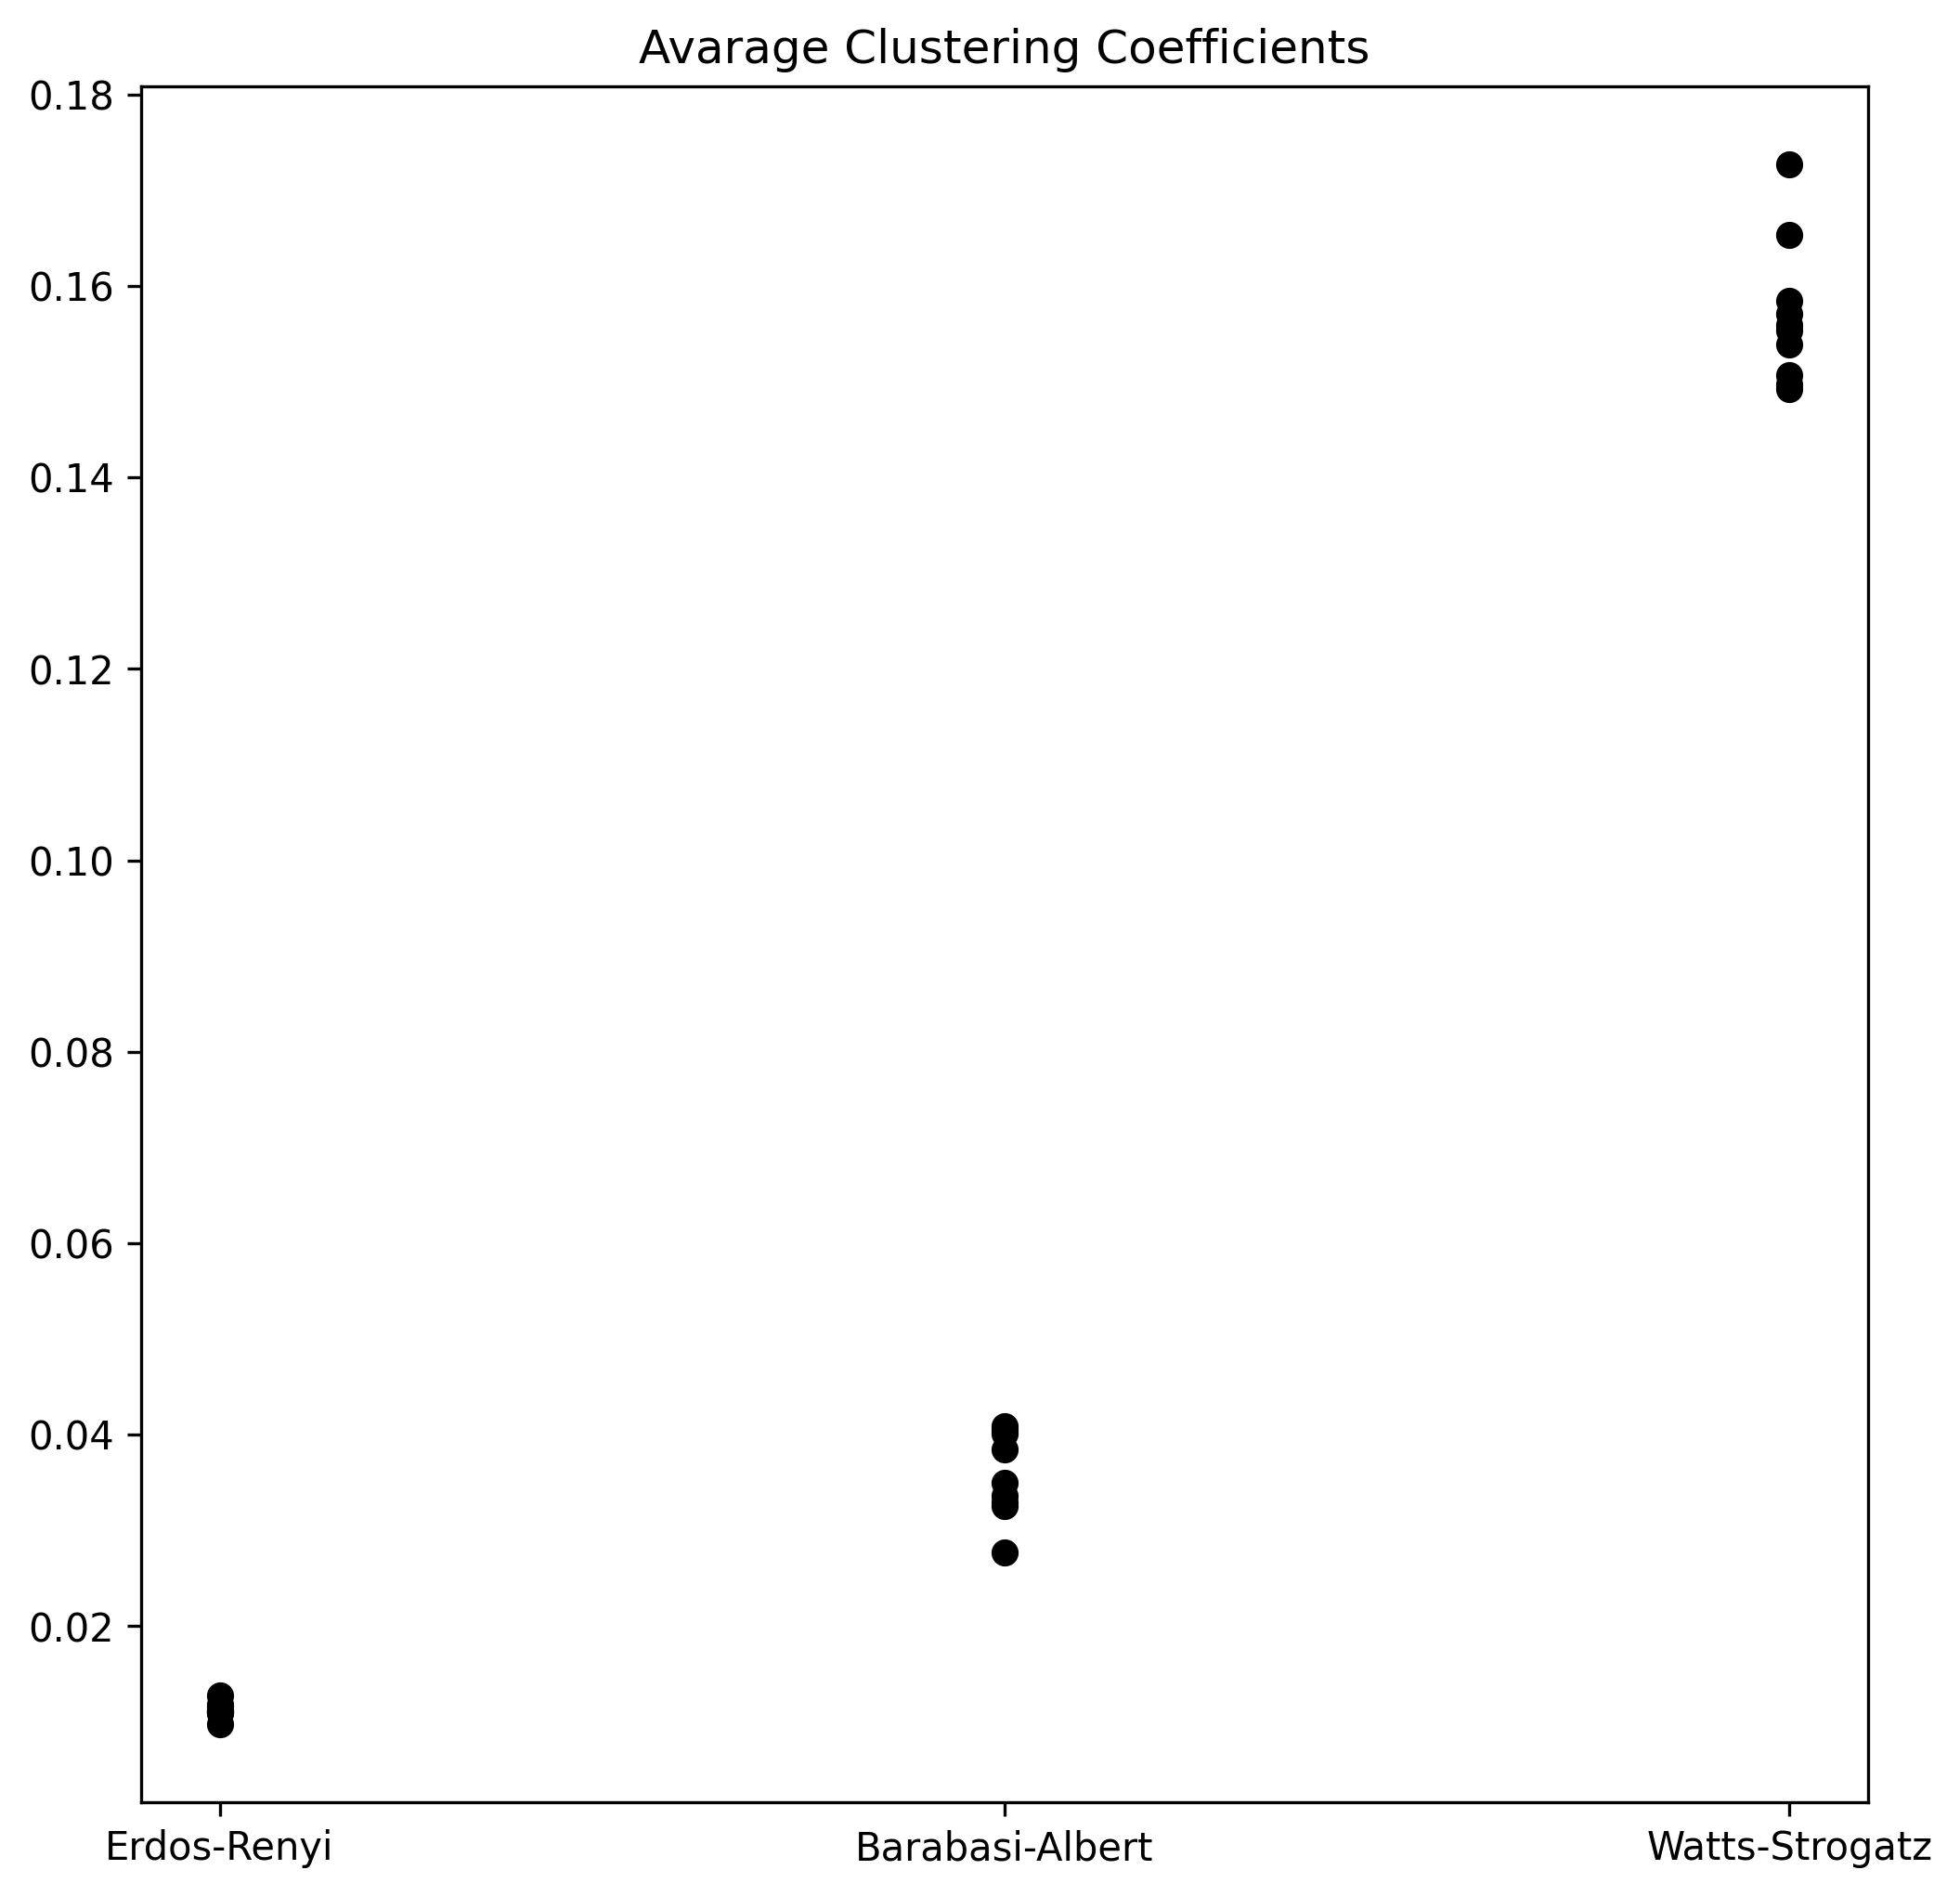

In [71]:
for graph in er_graphs:
    plt.scatter(1, nx.average_clustering(graph), c='k')
for graph in ba_graphs:
    plt.scatter(2, nx.average_clustering(graph), c='k')
for graph in ws_graphs:
    plt.scatter(3, nx.average_clustering(graph), c='k')
plt.xticks([1,2,3], ['Erdos-Renyi', 'Barabasi-Albert', 'Watts-Strogatz'])
plt.title("Avarage Clustering Coefficients")
plt.show()

(0.0, 40.0)

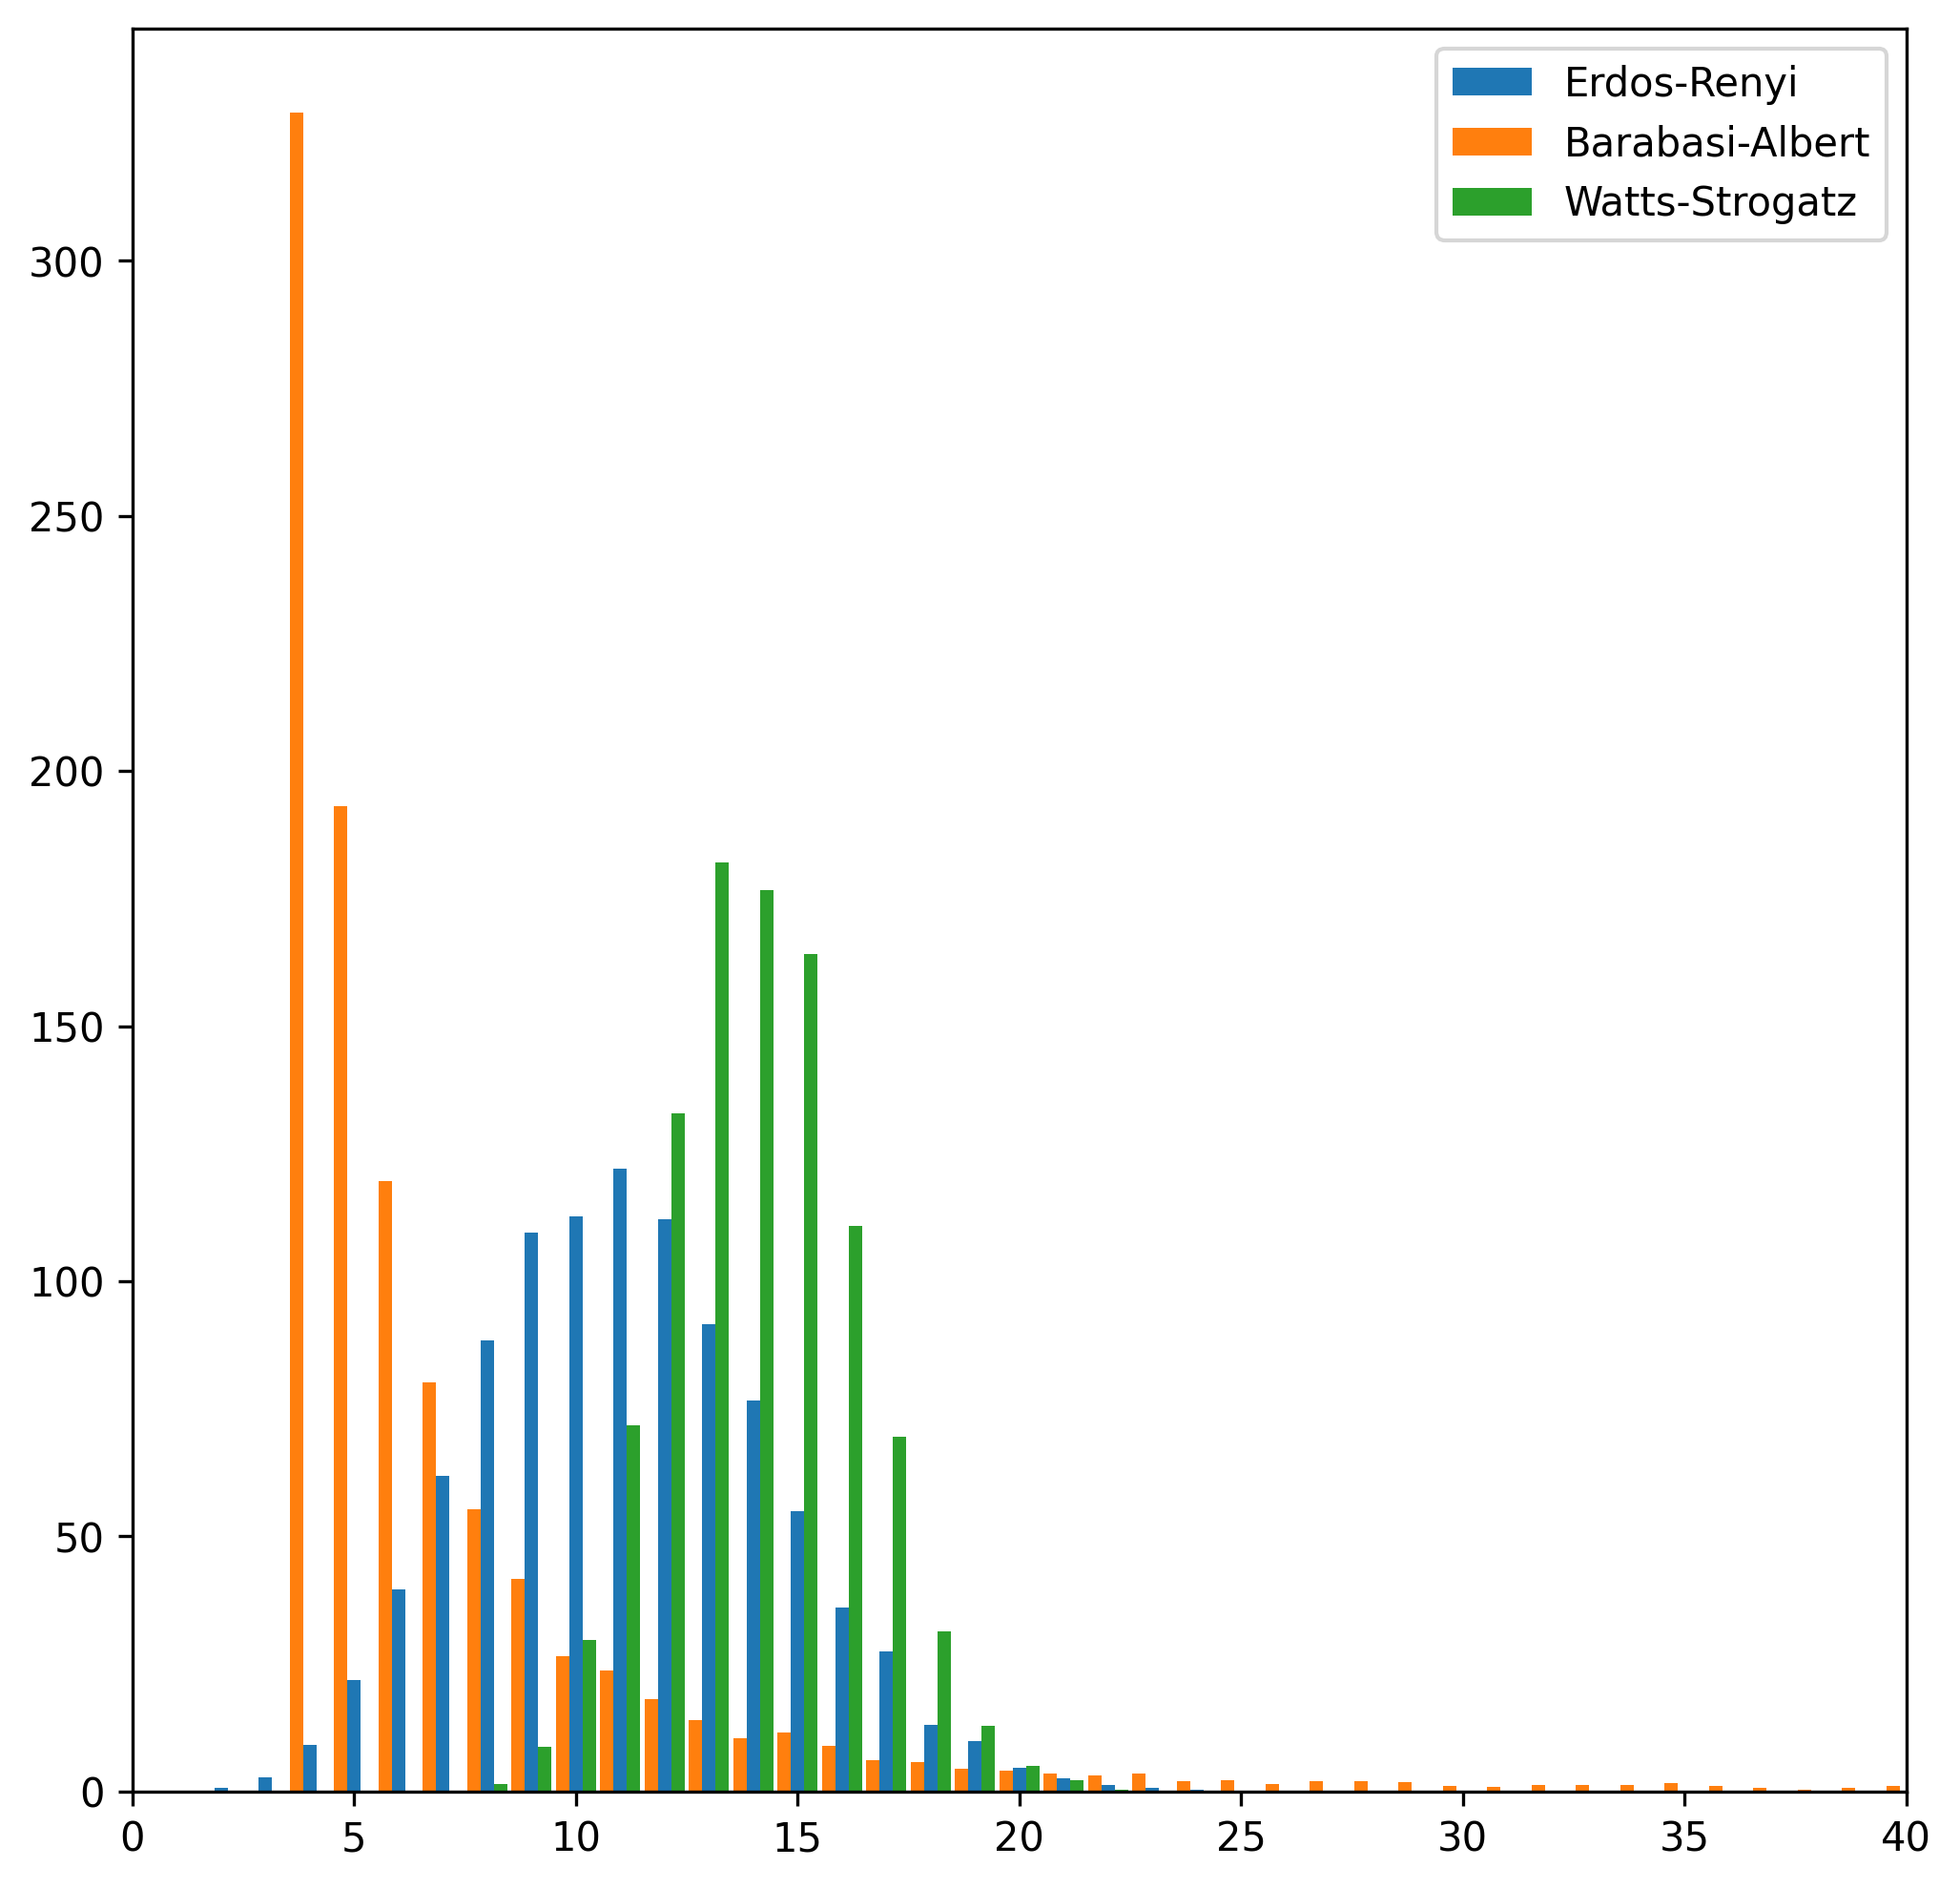

In [88]:
er_hist = np.array([0])
for graph in er_graphs:
    new_hist = np.array(nx.degree_histogram(graph))
    if len(new_hist) > len(er_hist):
        new_hist[:len(er_hist)] += er_hist
        er_hist = new_hist
    elif len(new_hist) < len(er_hist):
        er_hist[:len(new_hist)] += new_hist
    else:
        er_hist += new_hist
bar_width = 0.3
plt.bar(range(len(er_hist)), er_hist/len(er_graphs), width=0.3, label="Erdos-Renyi")

ba_hist = np.array([0])
for graph in ba_graphs:
    new_hist = np.array(nx.degree_histogram(graph))
    if len(new_hist) > len(ba_hist):
        new_hist[:len(ba_hist)] += ba_hist
        ba_hist = new_hist
    elif len(new_hist) < len(ba_hist):
        ba_hist[:len(new_hist)] += new_hist
    else:
        ba_hist += new_hist

plt.bar(np.arange(0,len(ba_hist))-bar_width, ba_hist/len(ba_graphs), width=0.3, label="Barabasi-Albert")


ws_hist = np.array([0])
for graph in ws_graphs:
    new_hist = np.array(nx.degree_histogram(graph))
    if len(new_hist) > len(ws_hist):
        new_hist[:len(ws_hist)] += ws_hist
        ws_hist = new_hist
    elif len(new_hist) < len(ws_hist):
        ws_hist[:len(new_hist)] += new_hist
    else:
        ws_hist += new_hist

plt.bar(np.arange(0,len(ws_hist))+bar_width, ws_hist/len(ws_graphs), width=0.3, label="Watts-Strogatz")
plt.legend()
plt.xlim(0, 40)

# Part 3

In [89]:
er_graph = er_graphs[-1]
ba_graph = ba_graphs[-1]
ws_graph = ws_graphs[-1]

  0%|          | 0/6 [00:00<?, ?it/s]

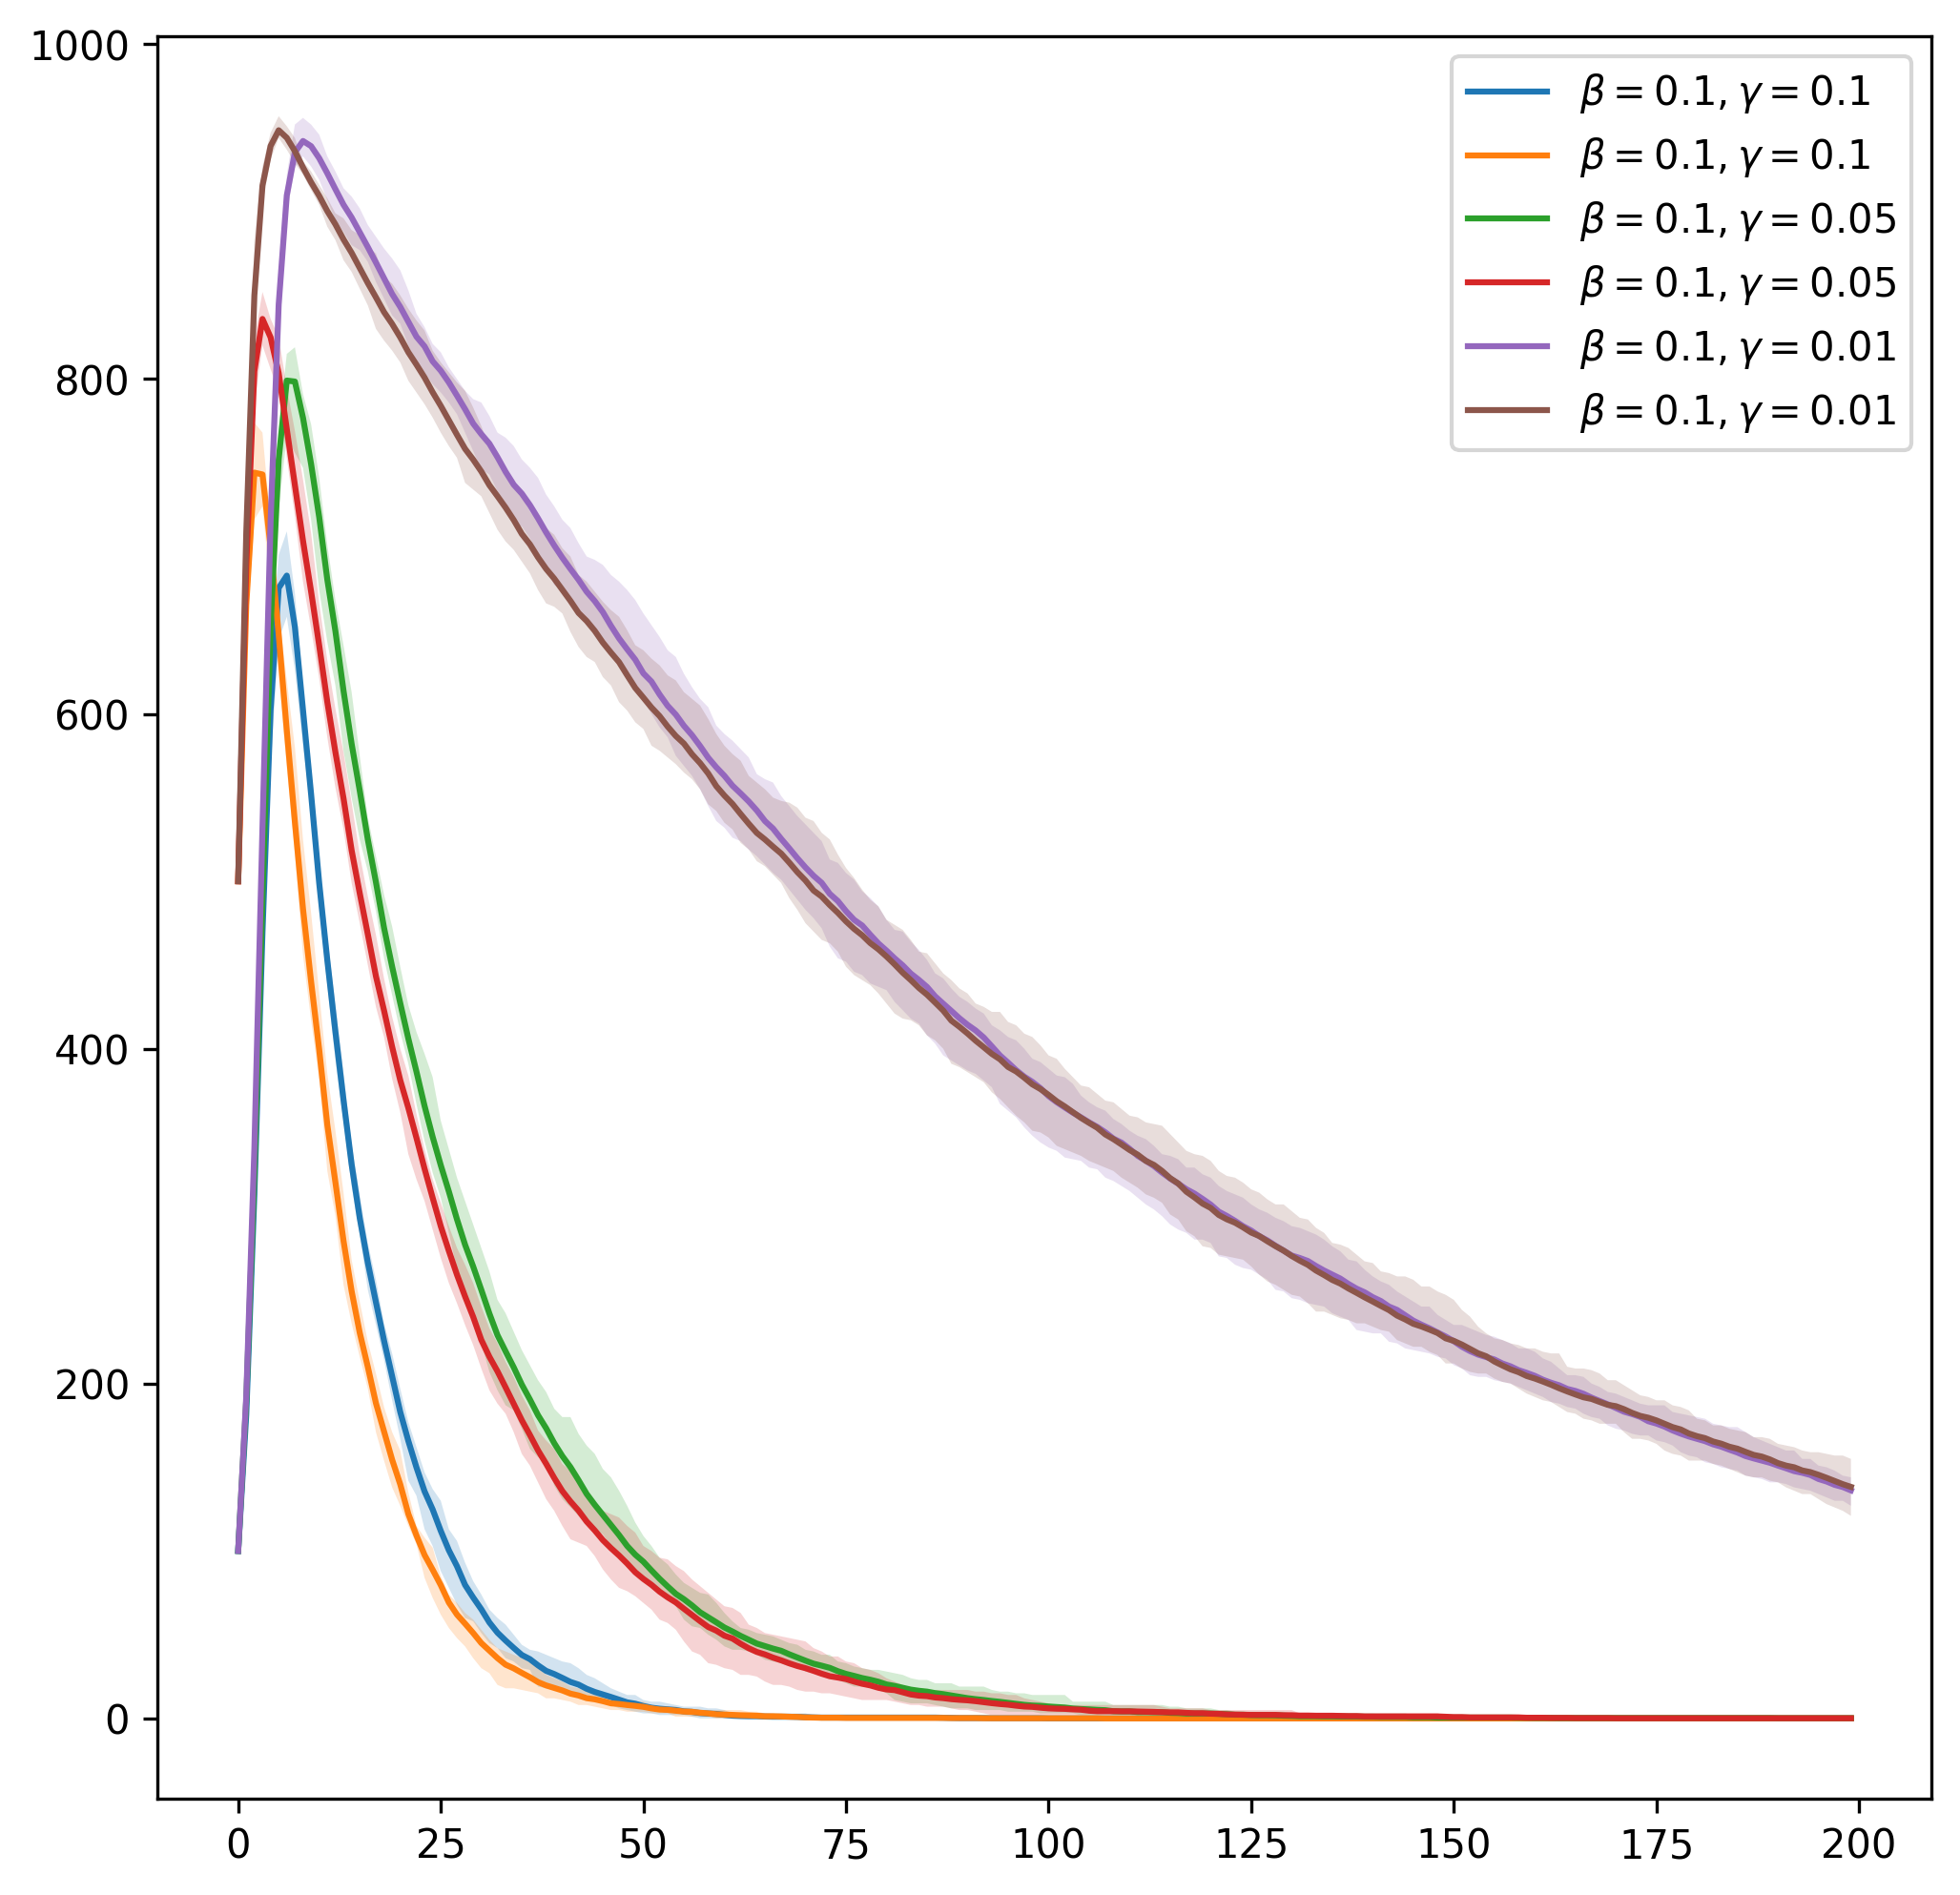

In [100]:
beta = 0.1
gamma_lst = [0.1, 0.05, 0.01]
i0_lst = [0.1, 0.5]
for (gamma, i0) in product(gamma_lst, i0_lst):
    er_model = simulate_SIR_n_times(er_graph, beta, gamma, i0, 10, 200)
    s_lst_er = er_model[:,0]
    s_er_min = np.min(s_lst_er, axis=0)
    s_er_mean = np.mean(s_lst_er, axis=0)
    s_er_max = np.max(s_lst_er, axis=0)
    i_lst_er = er_model[:,1]
    i_er_min = np.min(i_lst_er, axis=0)
    i_er_mean = np.mean(i_lst_er, axis=0)
    i_er_max = np.max(i_lst_er, axis=0)
    r_lst_er = er_model[:,2]
    r_er_min = np.min(r_lst_er, axis=0)
    r_er_mean = np.mean(r_lst_er, axis=0)
    r_er_max = np.max(r_lst_er, axis=0)
    plt.plot(range(len(i_er_mean)), i_er_mean, label=f"$\\beta = {beta}, \\gamma = {gamma}$")
    plt.fill_between(range(len(i_er_mean)), i_er_max, i_er_min, alpha=0.2)
    plt.legend()

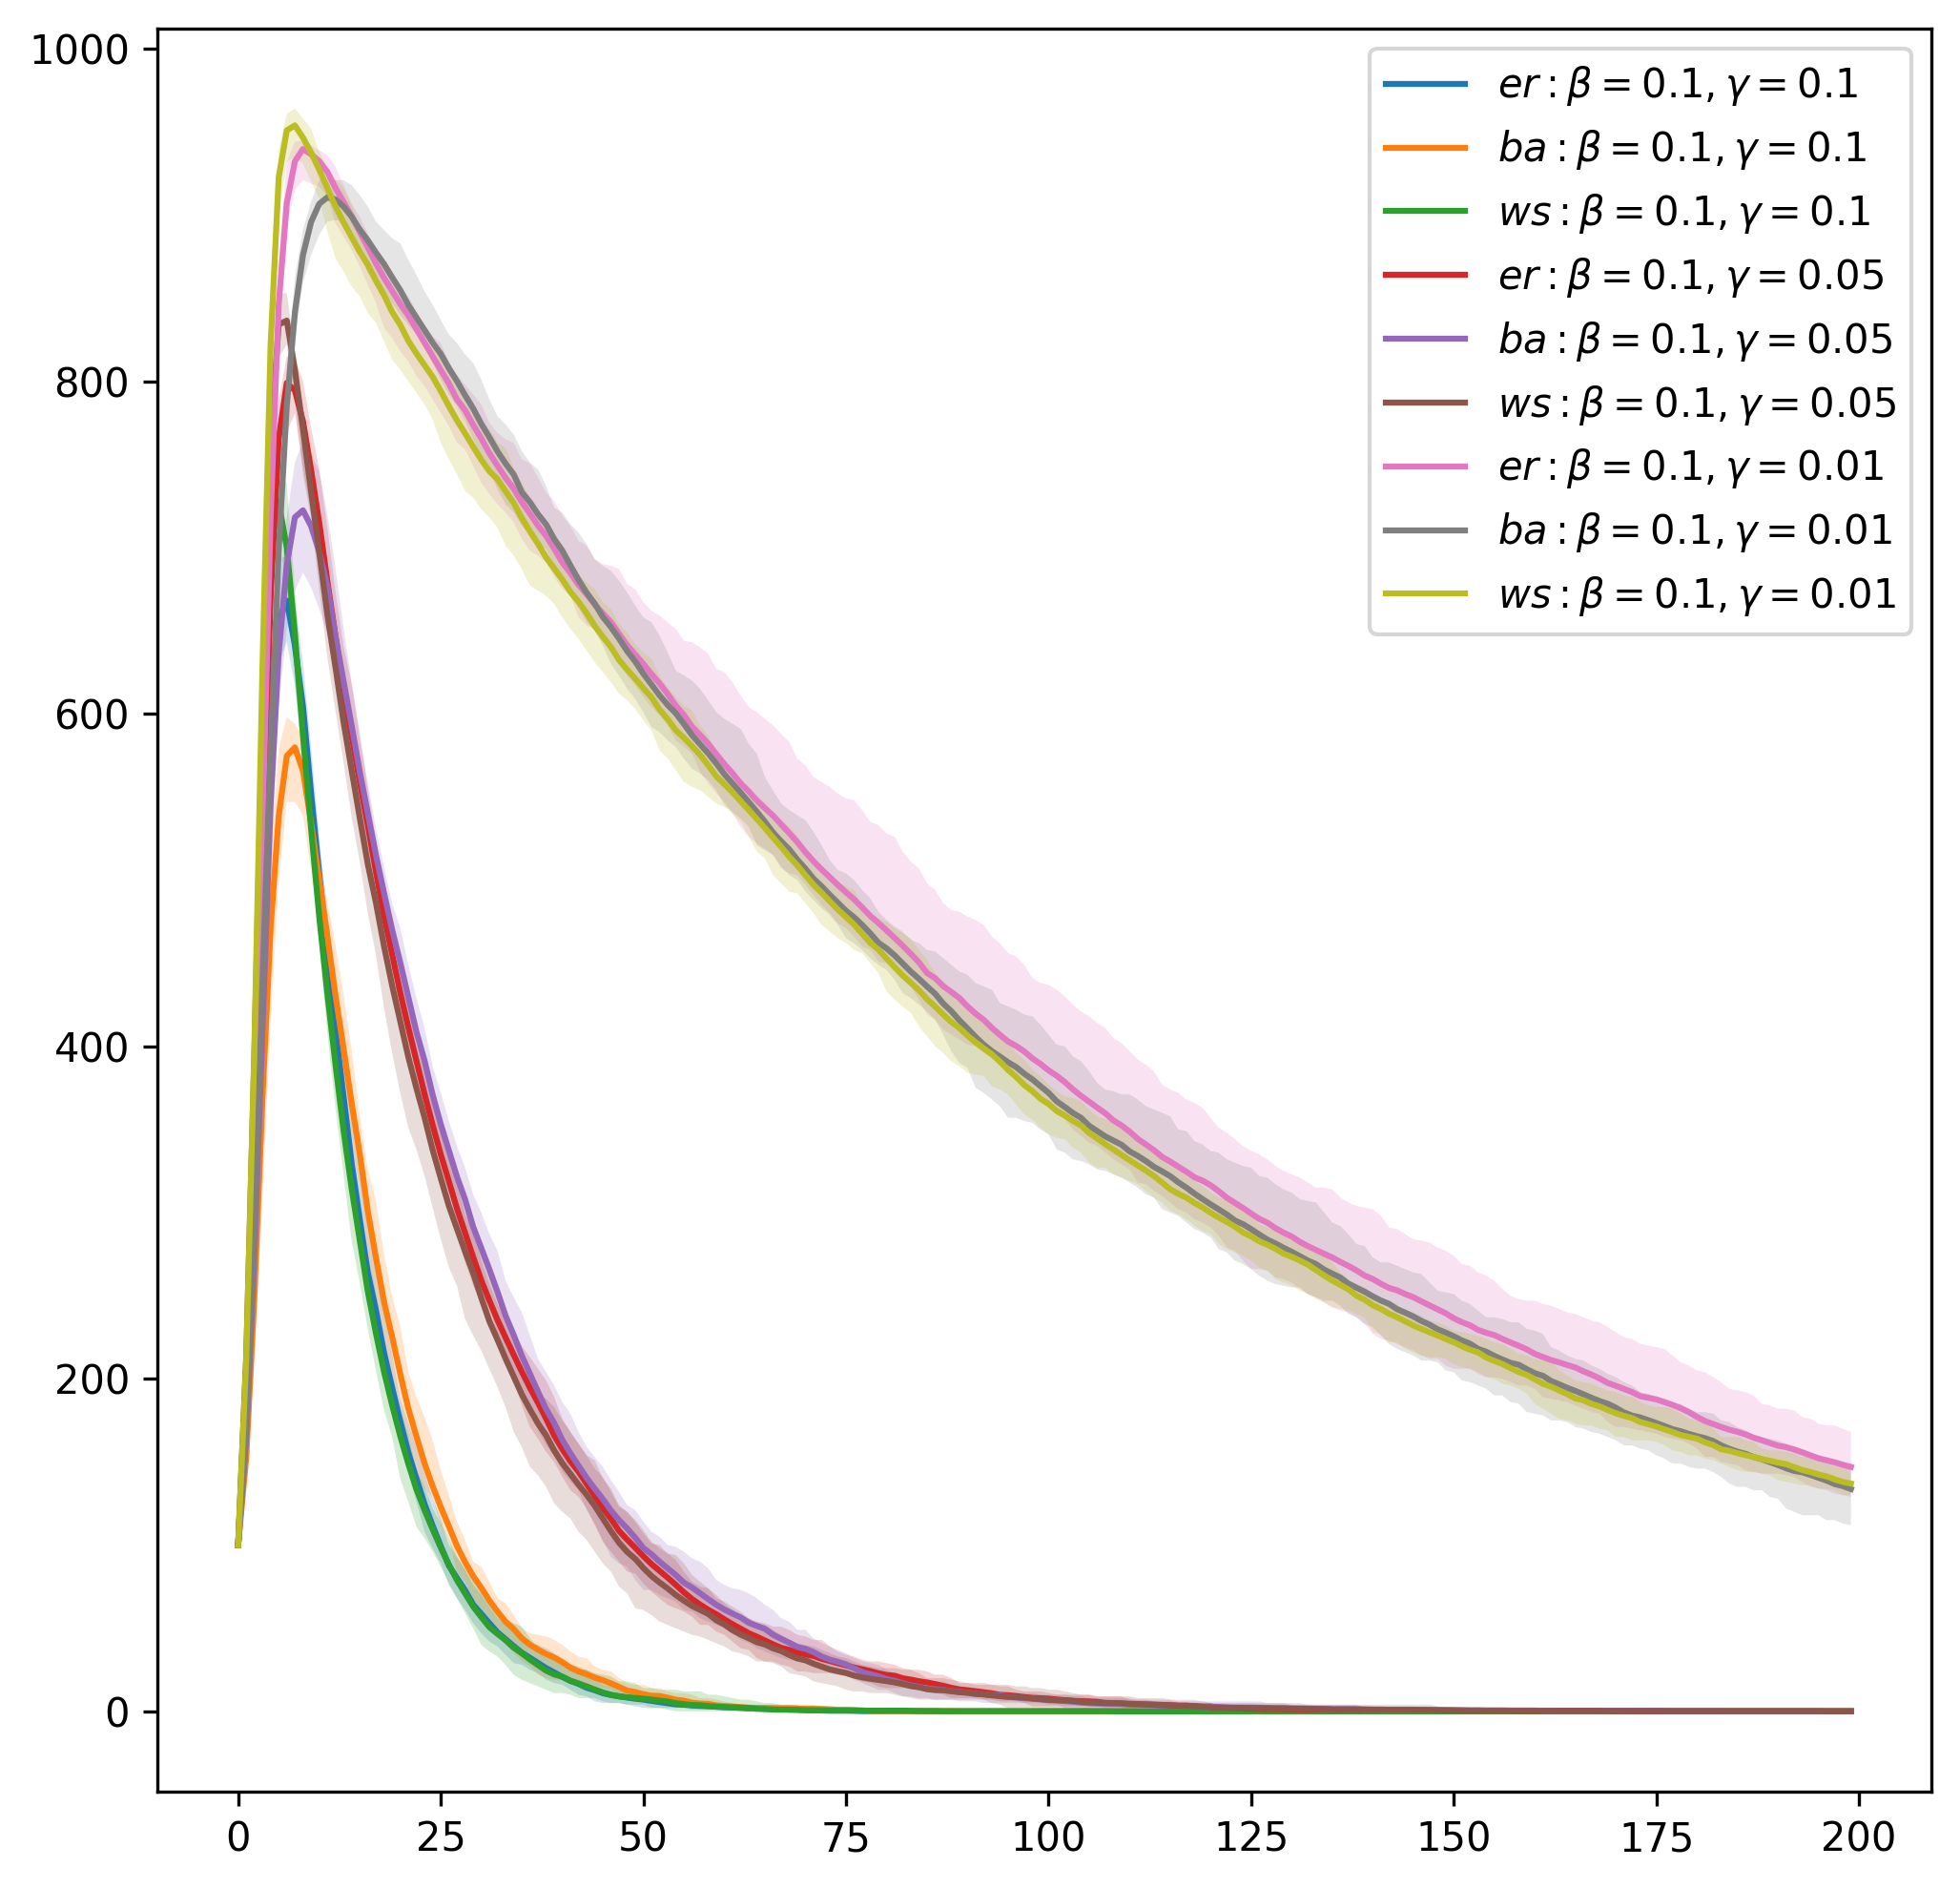

In [102]:
beta = 0.1
gamma_lst = [0.1, 0.05, 0.01]
i0 = 0.1
for gamma in gamma_lst:
    er_model = simulate_SIR_n_times(er_graph, beta, gamma, i0, 10, 200)
    ba_model = simulate_SIR_n_times(ba_graph, beta, gamma, i0, 10, 200)
    ws_model = simulate_SIR_n_times(ws_graph, beta, gamma, i0, 10, 200)
    i_lst_er = er_model[:,1]
    i_er_min = np.min(i_lst_er, axis=0)
    i_er_mean = np.mean(i_lst_er, axis=0)
    i_er_max = np.max(i_lst_er, axis=0)
    plt.plot(range(len(i_er_mean)), i_er_mean, label=f"$er: \\beta = {beta}, \\gamma = {gamma}$")
    plt.fill_between(range(len(i_er_mean)), i_er_max, i_er_min, alpha=0.2)
    i_lst_ba = ba_model[:,1]
    i_ba_min = np.min(i_lst_ba, axis=0)
    i_ba_mean = np.mean(i_lst_ba, axis=0)
    i_ba_max = np.max(i_lst_ba, axis=0)
    plt.plot(range(len(i_ba_mean)), i_ba_mean, label=f"$ba: \\beta = {beta}, \\gamma = {gamma}$")
    plt.fill_between(range(len(i_ba_mean)), i_ba_max, i_ba_min, alpha=0.2)
    i_lst_ws = ws_model[:,1]
    i_ws_min = np.min(i_lst_ws, axis=0)
    i_ws_mean = np.mean(i_lst_ws, axis=0)
    i_ws_max = np.max(i_lst_ws, axis=0)
    plt.plot(range(len(i_ws_mean)), i_ws_mean, label=f"$ws: \\beta = {beta}, \\gamma = {gamma}$")
    plt.fill_between(range(len(i_ws_mean)), i_ws_max, i_ws_min, alpha=0.2)
    plt.legend()

  0%|          | 0/6 [00:00<?, ?it/s]

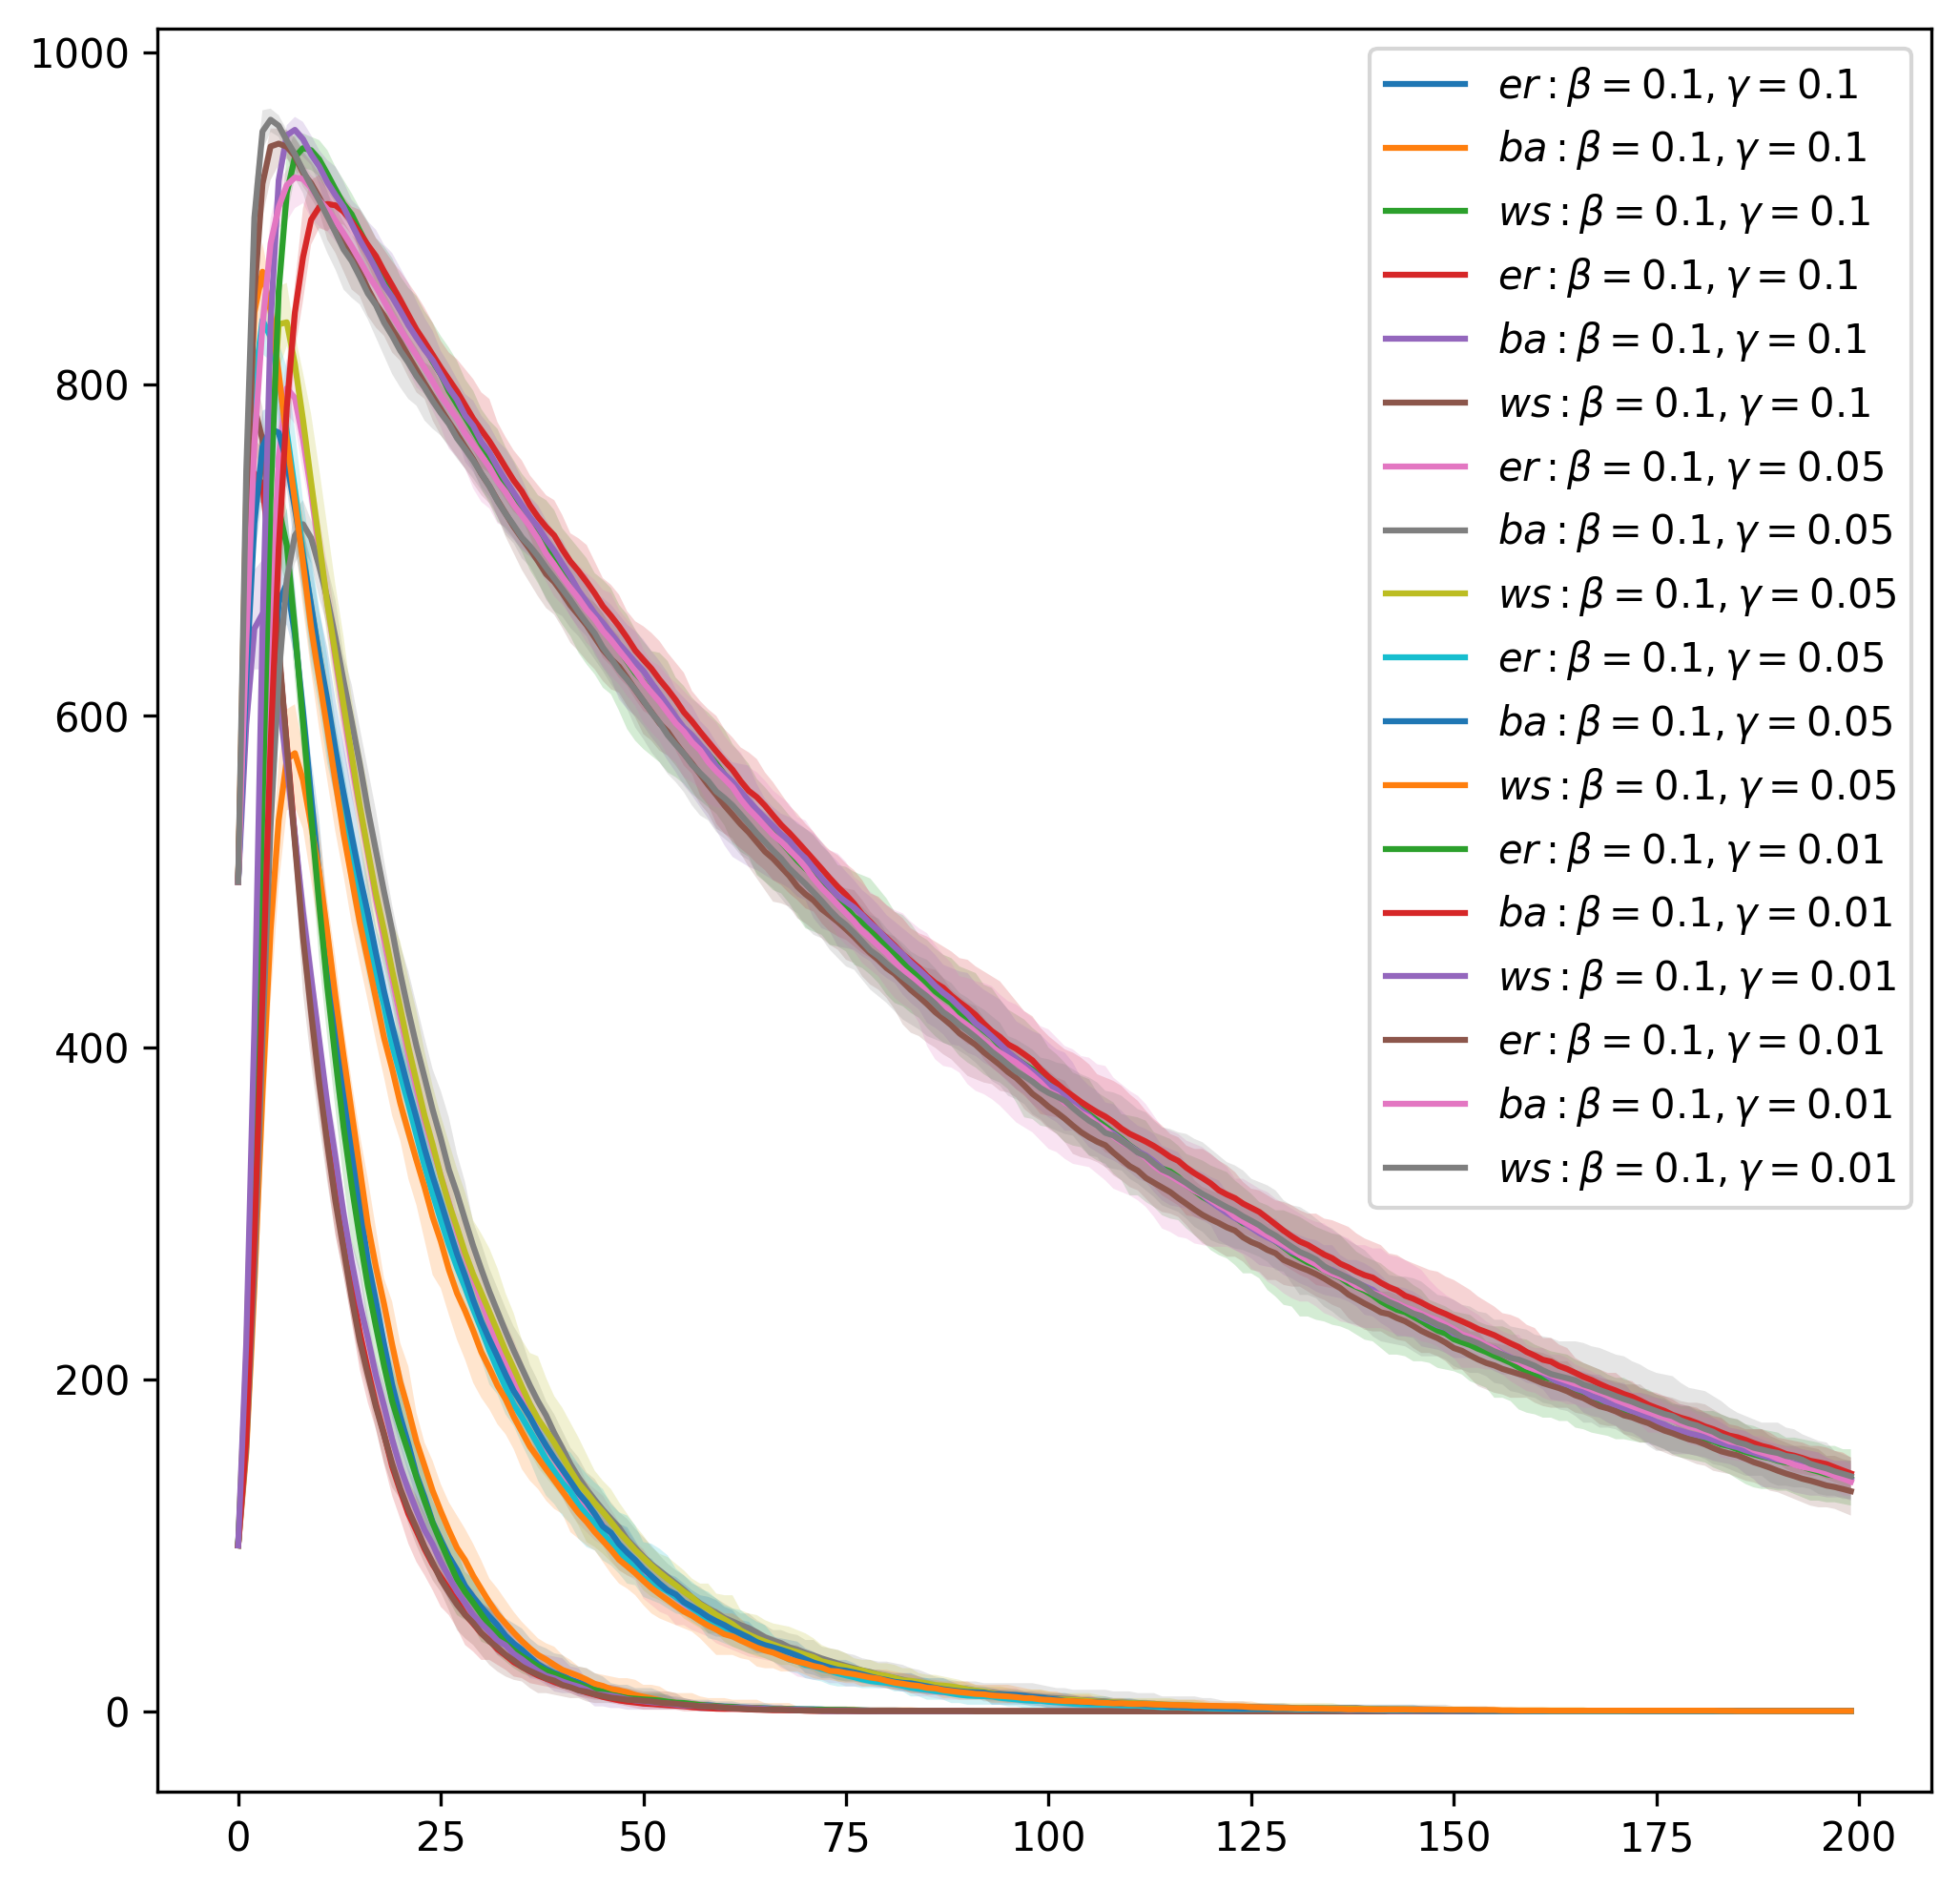

In [103]:

beta = 0.1
gamma_lst = [0.1, 0.05, 0.01]
i0_lst = [0.1, 0.5]
for (gamma, i0) in product(gamma_lst, i0_lst):
    er_model = simulate_SIR_n_times(er_graph, beta, gamma, i0, 10, 200)
    ba_model = simulate_SIR_n_times(ba_graph, beta, gamma, i0, 10, 200)
    ws_model = simulate_SIR_n_times(ws_graph, beta, gamma, i0, 10, 200)
    i_lst_er = er_model[:,1]
    i_er_min = np.min(i_lst_er, axis=0)
    i_er_mean = np.mean(i_lst_er, axis=0)
    i_er_max = np.max(i_lst_er, axis=0)
    plt.plot(range(len(i_er_mean)), i_er_mean, label=f"$er: \\beta = {beta}, \\gamma = {gamma}$")
    plt.fill_between(range(len(i_er_mean)), i_er_max, i_er_min, alpha=0.2)
    i_lst_ba = ba_model[:,1]
    i_ba_min = np.min(i_lst_ba, axis=0)
    i_ba_mean = np.mean(i_lst_ba, axis=0)
    i_ba_max = np.max(i_lst_ba, axis=0)
    plt.plot(range(len(i_ba_mean)), i_ba_mean, label=f"$ba: \\beta = {beta}, \\gamma = {gamma}$")
    plt.fill_between(range(len(i_ba_mean)), i_ba_max, i_ba_min, alpha=0.2)
    i_lst_ws = ws_model[:,1]
    i_ws_min = np.min(i_lst_ws, axis=0)
    i_ws_mean = np.mean(i_lst_ws, axis=0)
    i_ws_max = np.max(i_lst_ws, axis=0)
    plt.plot(range(len(i_ws_mean)), i_ws_mean, label=f"$ws: \\beta = {beta}, \\gamma = {gamma}$")
    plt.fill_between(range(len(i_ws_mean)), i_ws_max, i_ws_min, alpha=0.2)
    plt.legend()

# Part 4

In [122]:
adjacency_matrix_prime = np.genfromtxt('transmission_network.csv', delimiter=';', skip_header=1)[:,1:]
adjacency_matrix = np.where(adjacency_matrix_prime != 0, 1, 0)

array([[0, 1, 0, ..., 0, 0, 0],
       [1, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [124]:
graph_from_file = nx.from_numpy_array(adjacency_matrix)
print(graph_from_file)

Graph with 374 nodes and 1265 edges


In [144]:
plt.rcParams["figure.figsize"] = [25,25]
nx.draw(graph_from_file, pos=nx.nx_pydot.graphviz_layout(graph_from_file, prog="sfdp"))

In [145]:
plt.rcParams['figure.figsize'] = [10, 10]

In [ ]:
def simulate_and_vaccinate(model, vaccine_budget, testing_accuracy):

In [163]:
vaccine_model = ep.SIRModel(graph_from_file)
vaccine_config = mc.Configuration()
vaccine_config.add_model_parameter('beta', 0.1)
vaccine_config.add_model_parameter('gamma', 0.05)
vaccine_config.add_model_parameter('fraction_infected', 5/374)
vaccine_model.set_initial_status(vaccine_config)


iteration = [vaccine_model.iteration()]
iteration.append(vaccine_model.iteration())
trends = vaccinatable_model.build_trends()

vaccine_model.get_info()

# vaccine_model.build_trends()


{'beta': 0.1,
 'gamma': 0.05,
 'fraction_infected': 0.013368983957219251,
 'tp_rate': 1}